## Data Visualisation with Python

In [4]:
# Import the necessary libraries
import pandas as pd
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt
import datetime as dt
import gdown

## Step Process
1. Load Data
2. Inspect Data
3. Clean Data (if needed)
4. Explore + Visualise Data
5. Derive insights from Data Exploration/Visualisation

### Example 1: Forbes 2022 Data

#### 1. Load Data

In [5]:
forbes = pd.read_csv("forbes_2022.csv")
forbes

,Unnamed: 0,rank,name,networth,age,country,source,industry
0,0,1,Elon Musk,$219 B,50,United States,"Tesla, SpaceX",Automotive
1,1,2,Jeff Bezos,$171 B,58,United States,Amazon,Technology
2,2,3,Bernard Arnault & family,$158 B,73,France,LVMH,Fashion & Retail
3,3,4,Bill Gates,$129 B,66,United States,Microsoft,Technology
4,4,5,Warren Buffett,$118 B,91,United States,Berkshire Hathaway,Finance & Investments
...,...,...,...,...,...,...,...,...
2595,2595,2578,Jorge Gallardo Ballart,$1 B,80,Spain,pharmaceuticals,Healthcare
2596,2596,2578,Nari Genomal,$1 B,82,Philippines,apparel,Fashion & Retail
2597,2597,2578,Ramesh Genomal,$1 B,71,Philippines,apparel,Fashion & Retail
2598,2598,2578,Sunder Genomal,$1 B,68,Philippines,garments,Fashion & Retail


#### 2. Inspect Data

In [6]:
#If True, means duplicate
forbes.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2595    False
2596    False
2597    False
2598    False
2599    False
Length: 2600, dtype: bool

In [7]:
#sum of duplicated values
forbes.duplicated().sum()
#drop duplicates 
# forbes.drop_duplicates()

0

In [8]:
#sum of null values
forbes.isnull().sum()
#if has null value
#forbes.dropna()

Unnamed: 0    0
rank          0
name          0
networth      0
age           0
country       0
source        0
industry      0
dtype: int64

In [9]:
#Check data type, see if the type makes sense
forbes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  2600 non-null   int64 
 1   rank        2600 non-null   int64 
 2   name        2600 non-null   object
 3   networth    2600 non-null   object
 4   age         2600 non-null   int64 
 5   country     2600 non-null   object
 6   source      2600 non-null   object
 7   industry    2600 non-null   object
dtypes: int64(3), object(5)
memory usage: 162.6+ KB


#### 3. Clean Data

In [10]:
#Dtype is object indicates a generic type that can represent any Python object, including string, numbers..
#for a dataframe in pandas, it usually represents string

#Replace the $ and B with empty string
#str.replace(oldvalue,newvalue,count)
forbes["networth"]=forbes["networth"].str.replace('$','')
forbes["networth"]=forbes["networth"].str.replace('B','')
#Change type to numeric
forbes["networth"]=pd.to_numeric(forbes["networth"])
forbes



,Unnamed: 0,rank,name,networth,age,country,source,industry
0,0,1,Elon Musk,219.0,50,United States,"Tesla, SpaceX",Automotive
1,1,2,Jeff Bezos,171.0,58,United States,Amazon,Technology
2,2,3,Bernard Arnault & family,158.0,73,France,LVMH,Fashion & Retail
3,3,4,Bill Gates,129.0,66,United States,Microsoft,Technology
4,4,5,Warren Buffett,118.0,91,United States,Berkshire Hathaway,Finance & Investments
...,...,...,...,...,...,...,...,...
2595,2595,2578,Jorge Gallardo Ballart,1.0,80,Spain,pharmaceuticals,Healthcare
2596,2596,2578,Nari Genomal,1.0,82,Philippines,apparel,Fashion & Retail
2597,2597,2578,Ramesh Genomal,1.0,71,Philippines,apparel,Fashion & Retail
2598,2598,2578,Sunder Genomal,1.0,68,Philippines,garments,Fashion & Retail


#### 4. Explore Data

In [11]:
# Finding the industry with the highest number of billionaires
#value_counts() counts the frequency of unique values in specific columns of a dataframe
forbes["industry"].value_counts().sort_index()

industry
Automotive                      69
Construction & Engineering      43
Diversified                    178
Energy                          93
Fashion & Retail               246
Finance & Investments          386
Food & Beverage                201
Gambling & Casinos              23
Healthcare                     212
Logistics                       35
Manufacturing                  322
Media & Entertainment           95
Metals & Mining                 67
Real Estate                    189
Service                         51
Sports                          26
Technology                     329
Telecom                         35
Name: count, dtype: int64

In [12]:
#countries with most billionaires
forbes["country"].value_counts()

country
United States           719
China                   515
India                   161
Germany                 130
Russia                   81
                       ... 
Venezuela                 1
Portugal                  1
Algeria                   1
Eswatini (Swaziland)      1
Estonia                   1
Name: count, Length: 75, dtype: int64

In [13]:
# To display the top 5 industries with the most number of billionaires
forbes["industry"].value_counts()[:5]

industry
Finance & Investments     386
Technology                329
Manufacturing             322
Fashion & Retail          246
Healthcare                212
Name: count, dtype: int64

<Axes: xlabel='industry'>

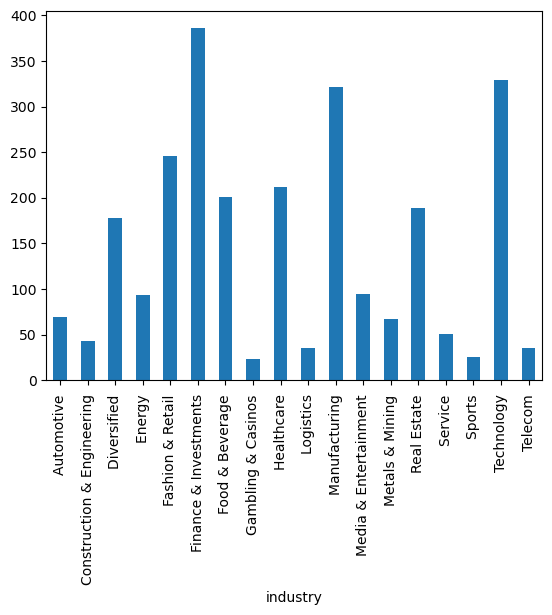

In [14]:
# show the number of billionaires in each industry with bar chart
forbes["industry"].value_counts().sort_index().plot(kind="bar")

<Axes: ylabel='industry'>

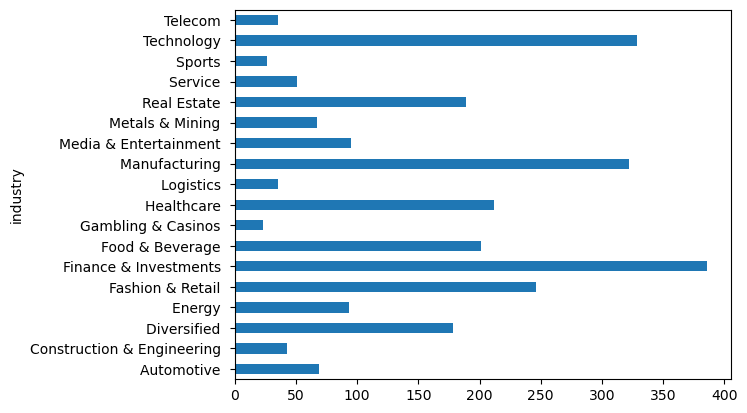

In [15]:
#Horizontal bar
forbes["industry"].value_counts().sort_index().plot(kind="barh")

In [16]:
# Finding the country with the highest number of billionaires
forbes["country"].value_counts()[:5]

country
United States    719
China            515
India            161
Germany          130
Russia            81
Name: count, dtype: int64

<Axes: xlabel='country'>

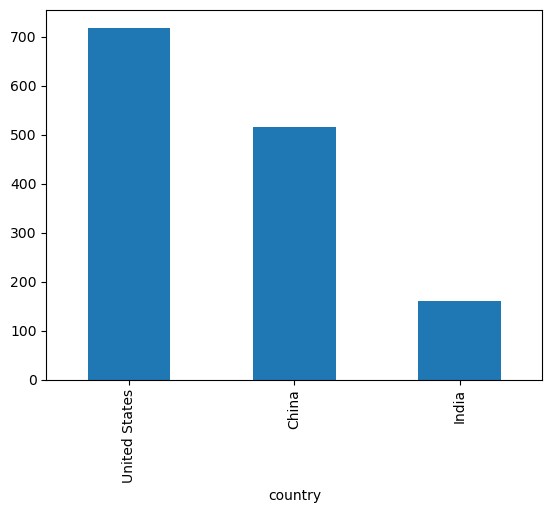

In [17]:
#display the top 3 countries with the most billionaries
forbes["country"].value_counts()[:3].plot(kind="bar")

In [18]:
# Find the billionaires with networth more than 60 billion dollars
#To filter a dataframe base on a condition, we need to use dataframe[condition] where the condition is a boolean expression
#condition=forbes['networth']>=60,True-more than or equal 60, False-less than 60
forbes[forbes["networth"]>=60]

,Unnamed: 0,rank,name,networth,age,country,source,industry
0,0,1,Elon Musk,219.0,50,United States,"Tesla, SpaceX",Automotive
1,1,2,Jeff Bezos,171.0,58,United States,Amazon,Technology
2,2,3,Bernard Arnault & family,158.0,73,France,LVMH,Fashion & Retail
3,3,4,Bill Gates,129.0,66,United States,Microsoft,Technology
4,4,5,Warren Buffett,118.0,91,United States,Berkshire Hathaway,Finance & Investments
5,5,6,Larry Page,111.0,49,United States,Google,Technology
6,6,7,Sergey Brin,107.0,48,United States,Google,Technology
7,7,8,Larry Ellison,106.0,77,United States,software,Technology
8,8,9,Steve Ballmer,91.4,66,United States,Microsoft,Technology
9,9,10,Mukesh Ambani,90.7,64,India,diversified,Diversified


In [19]:
#find the top 5 youngest billionaire
forbes.sort_values(by=["age"])[:5]

,Unnamed: 0,rank,name,networth,age,country,source,industry
1311,1311,1292,Kevin David Lehmann,2.4,19,Germany,drugstores,Fashion & Retail
2062,2062,1929,Wang Zelong,1.5,25,China,chemicals,Metals & Mining
1975,1975,1929,Pedro Franceschi,1.5,25,Brazil,fintech,Finance & Investments
2190,2190,2190,Alexandra Andresen,1.3,25,Norway,investments,Diversified
1961,1961,1929,Henrique Dubugras,1.5,26,Brazil,fintech,Finance & Investments


In [20]:
# Finding the top 5 youngest people who have networth of more than 50 billion
forbes_more_than_50=forbes[forbes["networth"]>=50]
forbes_more_than_50.sort_values(by=["age"])[:5]

#Or

,Unnamed: 0,rank,name,networth,age,country,source,industry
14,14,15,Mark Zuckerberg,67.3,37,United States,Facebook,Technology
24,24,25,Zhang Yiming,50.0,38,China,TikTok,Media & Entertainment
19,19,19,Changpeng Zhao,65.0,44,Canada,cryptocurrency exchange,Finance & Investments
6,6,7,Sergey Brin,107.0,48,United States,Google,Technology
5,5,6,Larry Page,111.0,49,United States,Google,Technology


In [21]:
# ig, ax=plt.subplots(figsize=(10,6))
# ax.hist(forbes.networth, bins=50, edgecolor="black", color="yellow")
# plt.show()

In [22]:
#Using the method we used previously

# the higher the bin, the closer it is to the distribution plot which will be explained later
#Notice the graphs are still similar to each other


##### Data Visualisation - Distribution Plot
- Shows how a variable in your data is distributed

# Distribution Plot

> parameter:
* data: dataframe name
* x,y,hue: variable name
* kind:{“hist”, “kde”, “ecdf”} hist by default, same as histplot(), kdeplot(), ecdfplot(univariate data only)
* color, palette, height...

1.   kernel density estimation:KDE represents the data using a continuous probability density curve, more smooth
2.    empirical cumulative distribution function: represents the proportion or counts of observations


/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


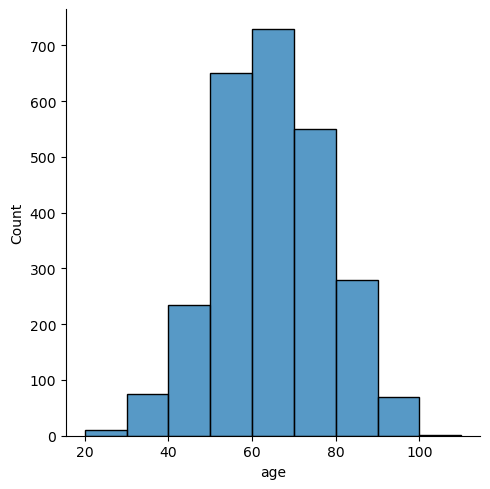

In [23]:
#Distribution plot of the age variable
sns.displot(x="age",data=forbes,bins=[ 20, 30, 40, 50, 60, 70,80,90,100,110])
plt.show()

Observation from dataset:
1. Most saturated industry/best industry (Finance & Investments)
2. Country with the most opportunity (US) - may be too saturated
3. Who to learn from (THose that really made it)
4. Probable age for someone to get really rich (50-70 years old)

### Example 2: Annual Sales 2018 Data

#### 1. Load Data

In [24]:
data=pd.read_csv("2018_annual.csv")
sales=data.copy()
sales

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,0,248151,AA Batteries (4-pack),4,3.84,2018-09-17 14:44:00,"883 West St, Boston, MA 02215"
1,1,248152,USB-C Charging Cable,2,11.95,2018-09-29 10:19:00,"71 Ridge St, New York City, NY 10001"
2,2,248153,USB-C Charging Cable,1,11.95,2018-09-16 17:48:00,"372 Spruce St, Portland, OR 97035"
3,3,248154,27in FHD Monitor,1,149.99,2018-09-27 07:52:00,"315 Meadow St, Atlanta, GA 30301"
4,4,248155,USB-C Charging Cable,1,11.95,2018-09-01 19:03:00,"408 Lake St, San Francisco, CA 94016"
...,...,...,...,...,...,...,...
185945,186845,150497,20in Monitor,1,109.99,2018-01-26 19:09:00,"697 West St, Dallas, TX 75001"
185946,186846,150498,27in FHD Monitor,1,149.99,2018-01-10 22:58:00,"611 Meadow St, Portland, OR 97035"
185947,186847,150499,ThinkPad Laptop,1,999.99,2018-01-21 14:31:00,"346 14th St, San Francisco, CA 94016"
185948,186848,150500,AAA Batteries (4-pack),2,2.99,2018-01-15 14:21:00,"789 Center St, Atlanta, GA 30301"


In [25]:
#parameter of drop: label, axis: 1 for column, 0 for index, default 0
#Better to name it with another variable so that you can keep the original dataset under the variable 'data'
sales=sales.drop("Unnamed: 0",axis=1)


#### 2. Inspect Data

In [26]:
sales.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
185945    False
185946    False
185947    False
185948    False
185949    False
Length: 185950, dtype: bool

In [27]:
sales.duplicated().sum()
# sales.drop_duplicates

0

In [28]:
sales.isnull().sum()
# sales.dropna()

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
dtype: int64

In [29]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Order ID          185950 non-null  int64  
 1   Product           185950 non-null  object 
 2   Quantity Ordered  185950 non-null  int64  
 3   Price Each        185950 non-null  float64
 4   Order Date        185950 non-null  object 
 5   Purchase Address  185950 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 8.5+ MB


#### 3. Clean Data

In [30]:
#Convert 'Order Date' column into datetime type
sales["Order Date"]=pd.to_datetime(sales["Order Date"])
#Create month and year column 
sales["Month"]=sales["Order Date"].dt.month
sales["Year"]=sales["Order Date"].dt.year
sales["Day"]=sales["Order Date"].dt.day
sales["Month"]=pd.to_numeric(sales["Month"])
sales["Order Date"]=pd.to_numeric(sales["Order Date"])

def get_city_from_address(address):
    substr=address.split(",")
    city=substr[1]
    return city

sales["Purchase Address"]=sales["Purchase Address"].apply(get_city_from_address)
sales

#Total Amount for each order
sales["Total Amount"]=sales["Quantity Ordered"]*sales["Price Each"]


#### 4. Explore Data

In [31]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Order ID          185950 non-null  int64  
 1   Product           185950 non-null  object 
 2   Quantity Ordered  185950 non-null  int64  
 3   Price Each        185950 non-null  float64
 4   Order Date        185950 non-null  int64  
 5   Purchase Address  185950 non-null  object 
 6   Month             185950 non-null  int32  
 7   Year              185950 non-null  int32  
 8   Day               185950 non-null  int32  
 9   Total Amount      185950 non-null  float64
dtypes: float64(2), int32(3), int64(3), object(2)
memory usage: 12.1+ MB


In [32]:
#Which month had the best sales?
sales["Month"].value_counts()
groupby_month=sales.groupby("Month")
gross_sales_by_month=groupby_month.sum().sort_values("Total Amount")["Total Amount"]
gross_sales_by_month


Month
1     1816846.41
9     2091892.33
2     2195978.76
8     2239309.25
6     2570410.65
7     2641281.10
3     2800592.49
5     3144348.98
11    3190667.83
4     3378020.92
10    3727769.15
12    4603683.90
Name: Total Amount, dtype: float64

In [33]:
#here Month is index label not variable


###### ***HOW THE PREVIOUS CODE LOOK LIKE (STEP BY STEP)***

In [34]:
#How it looks like, ingore the rest of the table except for Sales

In [35]:
 #Rearranging the sales amount in ascending amount

In [36]:
 #Get only the 'Sales' column

#### Data Visualisation

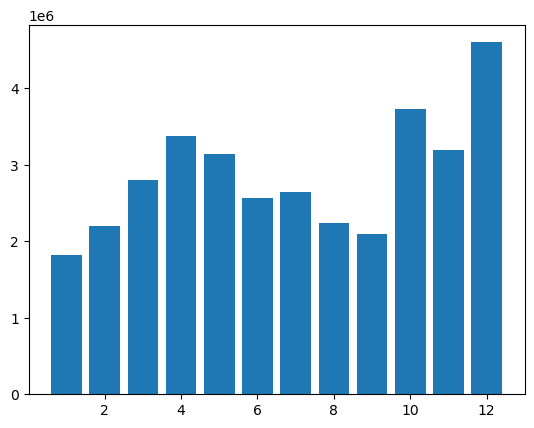

In [37]:
#Data Visualisation
plt.bar(gross_sales_by_month.index,gross_sales_by_month)
plt.show()

# what is def
  * def function name(argument):
  * statement
  * return expression

In [40]:
#Group data by cities
groupby_cities=sales.groupby("Purchase Address")
gross_sales_by_city=groupby_cities.sum().sort_values("Total Amount")["Total Amount"]
gross_sales_by_city

plt.bar(gross_sales_by_city.index,gross_sales_by_city)
plt.show()



In [52]:
#Which city makes the best sales across all 12 months



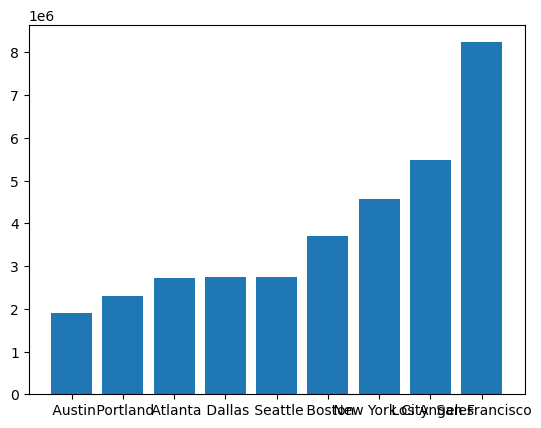

In [49]:
# Can query individual cities (Example: Atlanta)


In [44]:
#query each month sales for specific city


# create a line chart to show how the sale change in each city for 12 months?

In [54]:
# Get a list of cities
#so there will be no duplicate
cities=sales["Purchase Address"].unique()
cities


array([' Boston', ' New York City', ' Portland', ' Atlanta',
       ' San Francisco', ' Dallas', ' Austin', ' Los Angeles', ' Seattle'],
      dtype=object)

In [46]:
fig, ax= plt.subplots(figsize=(15,8))

for city in cities:
    current_sales = groupby_data.loc[:,city]
    ax.plot(current_sales,label=city)


  #Plot line plot for this city
  #parameter: only y is required
